In [1]:
# ============================================================
# CELL 1 — MASTER SETUP
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

BASE      = '/content/drive/MyDrive/final_project/'
MODEL_DIR = BASE + 'models/'

# Load data
train_df = pd.read_csv(BASE + 'df_train.csv')
test_df  = pd.read_csv(BASE + 'df_test.csv')

# Fix column names
for df_ in [train_df, test_df]:
    df_.columns = df_.columns.str.strip()\
                             .str.lower()\
                             .str.replace(' ', '_')

# Fix numeric columns
numeric_cols = [
    'customer_age', 'customer_satisfaction_rating',
    'word_count', 'char_count', 'sentiment_score',
    'channel_encoded', 'gender_encoded',
    'product_encoded', 'ticket_age_days',
    'ticket_type_encoded', 'ticket_priority_encoded'
]
for df_ in [train_df, test_df]:
    for col in numeric_cols:
        if col in df_.columns:
            df_[col] = pd.to_numeric(
                df_[col], errors='coerce').fillna(0)

print("Setup complete!")
print("Train:", train_df.shape)
print("Test :", test_df.shape)

Mounted at /content/drive
Setup complete!
Train: (5928, 31)
Test : (1271, 31)


In [2]:
# ============================================================
# CELL 2 — ADD KEYWORD FEATURES
# ============================================================
keyword_signals = {
    'billing'      : ['bill','payment','charge','invoice',
                      'price','cost','fee','refund',
                      'money','amount','pay'],
    'technical'    : ['error','bug','crash','install','update',
                      'software','hardware','device','broken',
                      'fix','issue','problem','work',
                      'connect','battery'],
    'cancellation' : ['cancel','cancelation','subscription',
                      'stop','end','terminate','close',
                      'discontinue','quit'],
    'refund'       : ['refund','return','money back',
                      'reimburse','exchange','replace',
                      'credit','compensate'],
    'product'      : ['product','feature','how','work',
                      'use','setup','configure',
                      'compatible','spec','model']
}

# Find correct description column
desc_cols = [c for c in train_df.columns
             if 'desc' in c.lower() or 'description' in c.lower()]
desc_col  = desc_cols[0] if desc_cols else 'ticket_description'
print(f"Using description column: {desc_col}")

# Add keyword features
for cat, keywords in keyword_signals.items():
    for df_ in [train_df, test_df]:
        df_[f'kw_{cat}'] = df_[desc_col].fillna('').apply(
            lambda x: sum(1 for kw in keywords
                         if kw in str(x).lower()))

# Define feature list
feature_cols = [
    'customer_age',    'channel_encoded',  'gender_encoded',
    'product_encoded', 'ticket_age_days',
    'word_count',      'char_count',       'sentiment_score',
    'kw_billing',      'kw_technical',     'kw_cancellation',
    'kw_refund',       'kw_product'
]

# Build feature matrices
X_train_shap = train_df[feature_cols].fillna(0)
X_test_shap  = test_df[feature_cols].fillna(0)
y_train      = train_df['ticket_type_encoded'].astype(int)
y_test       = test_df['ticket_type_encoded'].astype(int)

print(f"X_train_shap : {X_train_shap.shape}")
print(f"X_test_shap  : {X_test_shap.shape}")
print(f"Features     : {feature_cols}")

# Verify keyword values
print("\nKeyword feature sample:")
print(X_train_shap[['kw_billing','kw_technical',
                     'kw_cancellation','kw_refund',
                     'kw_product']].head(3))

Using description column: ticket_description
X_train_shap : (5928, 13)
X_test_shap  : (1271, 13)
Features     : ['customer_age', 'channel_encoded', 'gender_encoded', 'product_encoded', 'ticket_age_days', 'word_count', 'char_count', 'sentiment_score', 'kw_billing', 'kw_technical', 'kw_cancellation', 'kw_refund', 'kw_product']

Keyword feature sample:
   kw_billing  kw_technical  kw_cancellation  kw_refund  kw_product
0           0             2                0          0           1
1           0             2                0          0           1
2           0             3                0          0           4


In [3]:
# ============================================================
# CELL 3 — TRAIN XGBoost ON 13 FEATURES
# ============================================================
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score

xgb_shap = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
xgb_shap.fit(X_train_shap, y_train)

y_pred = xgb_shap.predict(X_test_shap)
f1     = f1_score(y_test, y_pred, average='macro')
acc    = accuracy_score(y_test, y_pred)

print(f"Features used : {xgb_shap.n_features_in_}")
print(f"Accuracy      : {acc:.4f}")
print(f"F1 Macro      : {f1:.4f}")

joblib.dump(xgb_shap, MODEL_DIR + 'xgb_shap.pkl')
print("Model saved!")

Features used : 13
Accuracy      : 0.1967
F1 Macro      : 0.1949
Model saved!


In [4]:
# ============================================================
# CELL 4 — COMPUTE SHAP VALUES
# ============================================================
print("Computing SHAP values...")

explainer   = shap.TreeExplainer(xgb_shap)
shap_values = explainer.shap_values(X_test_shap)
shap_array  = np.array(shap_values)

print(f"SHAP array shape : {shap_array.shape}")

# Determine correct averaging axis based on shape
# Shape (samples, features, classes) → axis=(0,2)
# Shape (classes, samples, features) → axis=(0,1)
if shap_array.ndim == 3:
    if shap_array.shape[1] == len(feature_cols):
        # shape is (samples, features, classes)
        print("Shape format: (samples, features, classes)")
        mean_abs_shap = np.abs(shap_array).mean(axis=(0, 2))
    else:
        # shape is (classes, samples, features)
        print("Shape format: (classes, samples, features)")
        mean_abs_shap = np.abs(shap_array).mean(axis=(0, 1))
elif shap_array.ndim == 2:
    print("Shape format: (samples, features)")
    mean_abs_shap = np.abs(shap_array).mean(axis=0)

print(f"mean_abs_shap shape : {mean_abs_shap.shape}")
print(f"feature_cols length : {len(feature_cols)}")

# Build importance dataframe
importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 5 most important features:")
print(importance_df.head(5).to_string(index=False))

Computing SHAP values...
SHAP array shape : (1271, 13, 5)
Shape format: (samples, features, classes)
mean_abs_shap shape : (13,)
feature_cols length : 13

Top 5 most important features:
        feature  importance
     char_count    0.159503
ticket_age_days    0.159464
   customer_age    0.136932
     word_count    0.131029
sentiment_score    0.123174


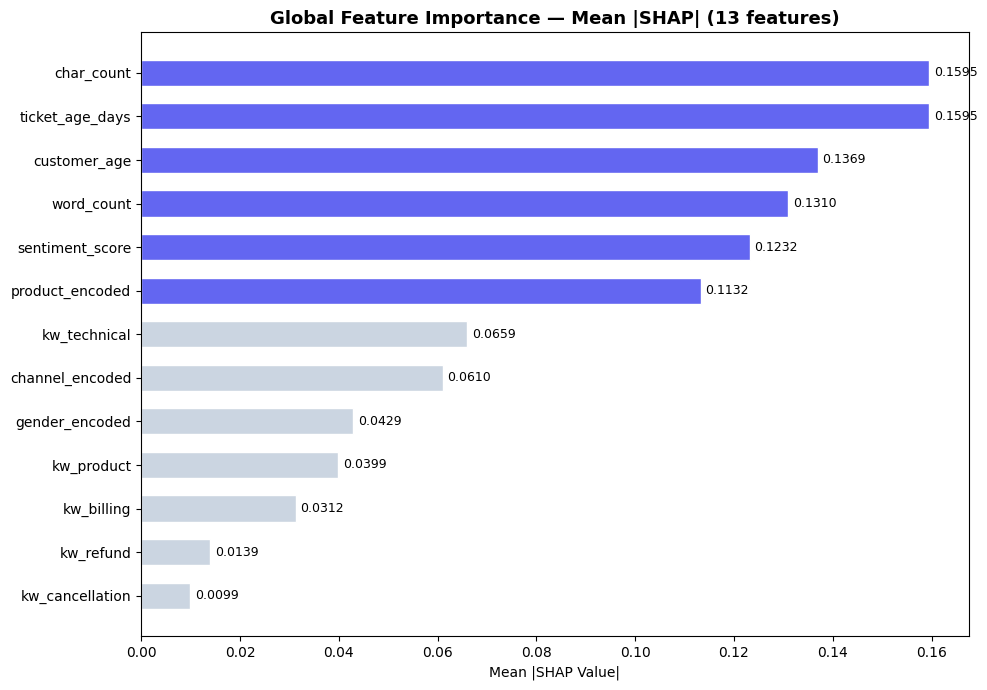

Global importance plot saved!


In [5]:
# ============================================================
# CELL 5 — GLOBAL IMPORTANCE BAR PLOT
# ============================================================
plot_df = importance_df.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
colors_ = ['#6366f1' if imp > importance_df['importance'].median()
           else '#cbd5e1'
           for imp in plot_df['importance']]

bars = plt.barh(plot_df['feature'],
                plot_df['importance'],
                color=colors_, edgecolor='white', height=0.6)

# Add value labels
for bar, val in zip(bars, plot_df['importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.title('Global Feature Importance — Mean |SHAP| (13 features)',
          fontweight='bold', fontsize=13)
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig(BASE + 'plots/shap_global_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Global importance plot saved!")

Classes: ['Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request', 'Technical issue']


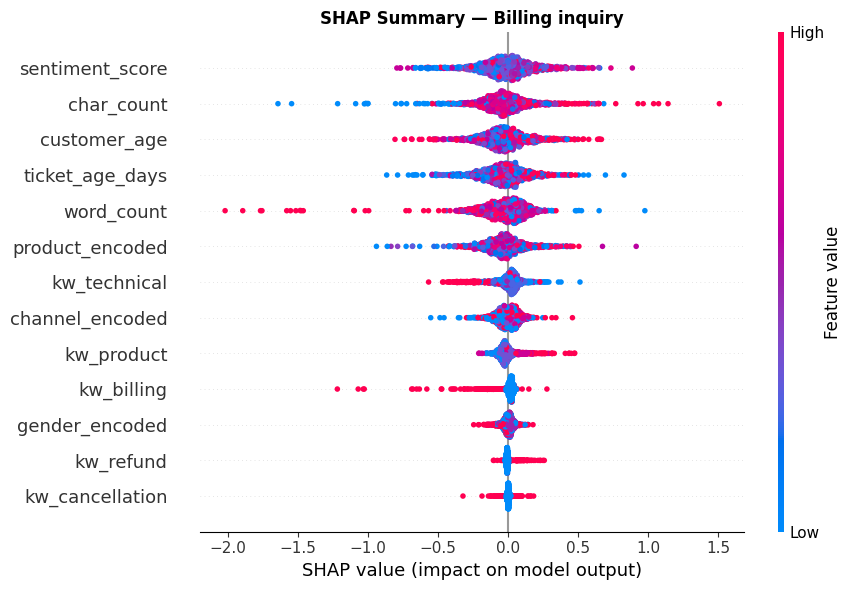

  Saved: shap_summary_Billing_inquiry.png


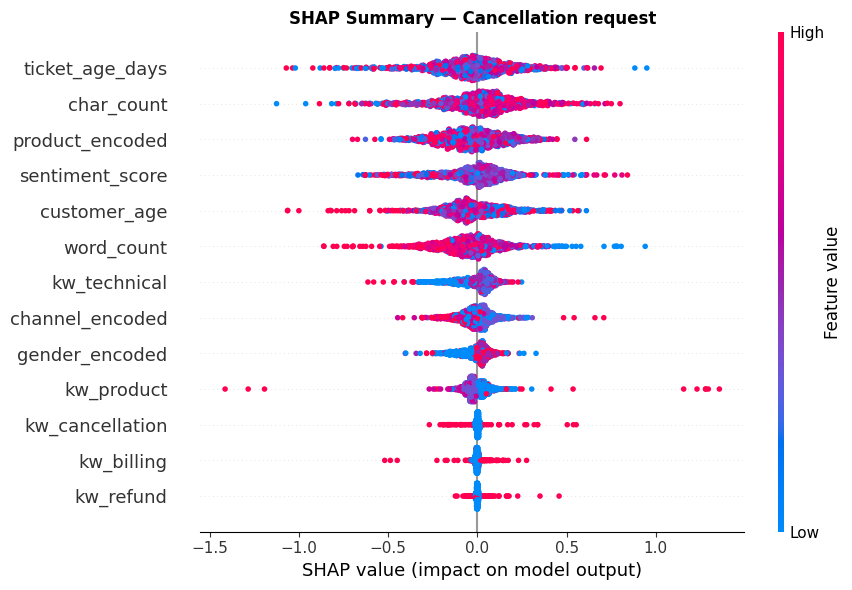

  Saved: shap_summary_Cancellation_request.png


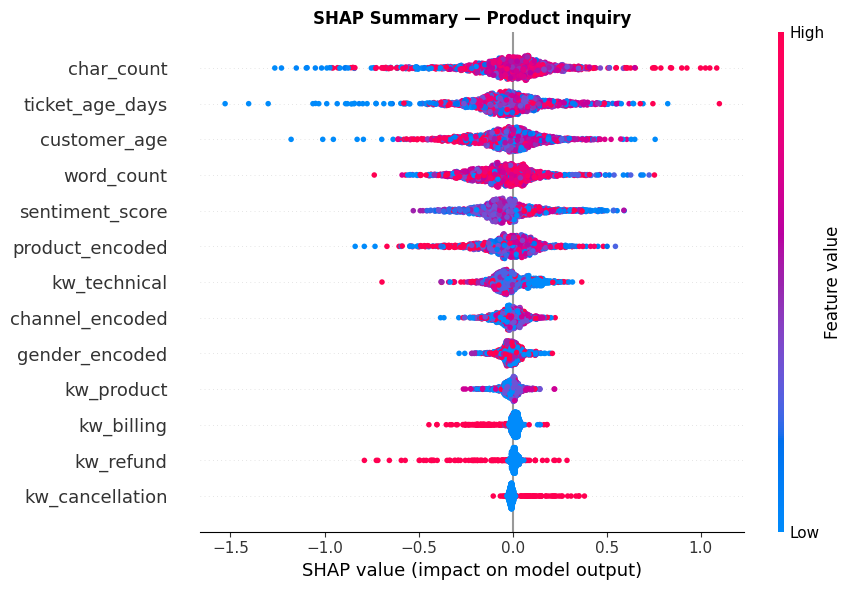

  Saved: shap_summary_Product_inquiry.png


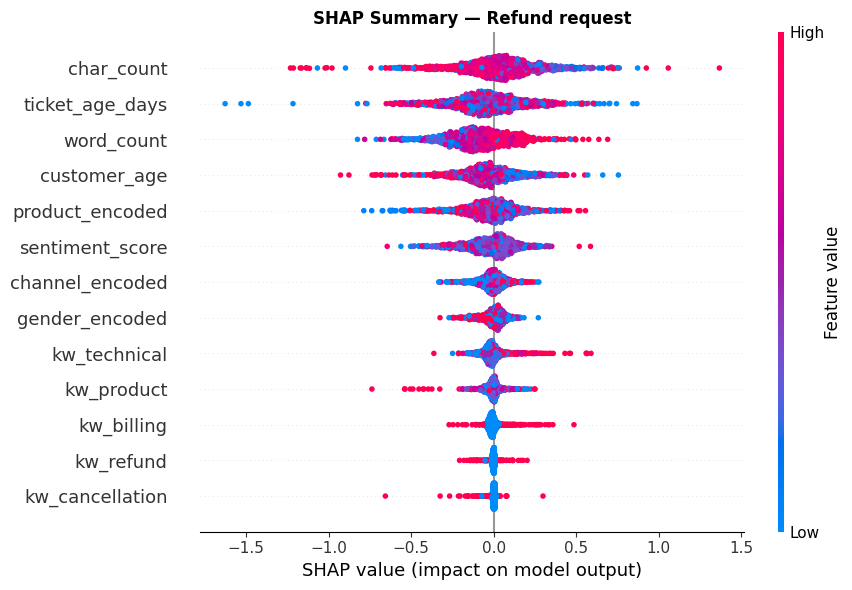

  Saved: shap_summary_Refund_request.png


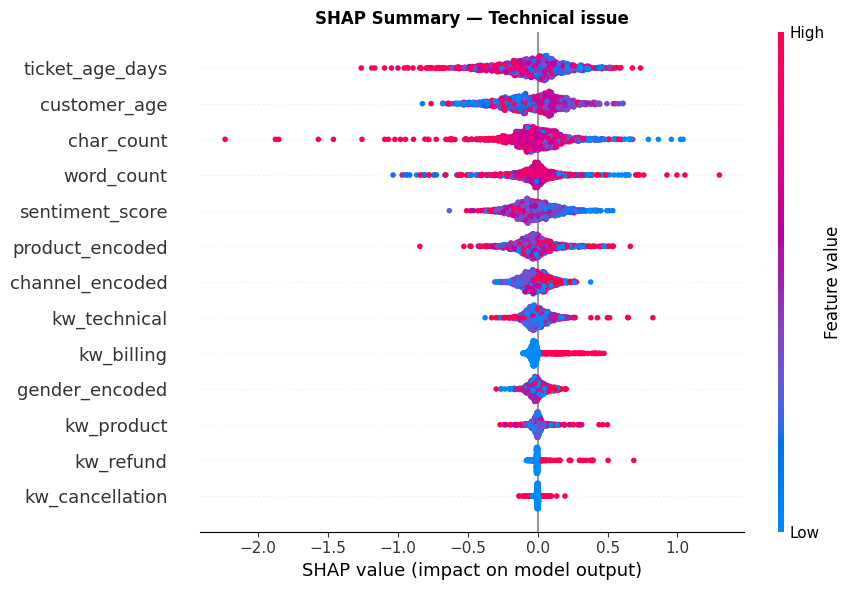

  Saved: shap_summary_Technical_issue.png

All summary plots saved!


In [6]:
# ============================================================
# CELL 6 — SHAP SUMMARY PLOTS PER CLASS
# ============================================================
le_type = joblib.load(MODEL_DIR + 'le_type.pkl')
print(f"Classes: {le_type.classes_.tolist()}")

for i, class_name in enumerate(le_type.classes_):
    plt.figure(figsize=(9, 6))

    # Extract correct SHAP slice based on shape
    if shap_array.shape[1] == len(feature_cols):
        # (samples, features, classes)
        class_shap = shap_array[:, :, i]
    else:
        # (classes, samples, features)
        class_shap = shap_array[i]

    shap.summary_plot(
        class_shap,
        X_test_shap,
        feature_names=feature_cols,
        show=False,
        plot_size=None
    )
    plt.title(f'SHAP Summary — {class_name}',
              fontweight='bold', fontsize=12)
    plt.tight_layout()
    safe = class_name.replace(' ','_').replace('/','_')
    plt.savefig(BASE + f'plots/shap_summary_{safe}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: shap_summary_{safe}.png")

print("\nAll summary plots saved!")

Sample index  : 5
True label    : Cancellation request
Predicted     : Cancellation request

Feature values:
  customer_age             : 20.00
  channel_encoded          : 3.00
  gender_encoded           : 0.00
  product_encoded          : 35.00
  ticket_age_days          : 901.00
  word_count               : 50.00
  char_count               : 270.00
  sentiment_score          : 0.46
  kw_billing               : 0.00
  kw_technical             : 4.00
  kw_cancellation          : 0.00
  kw_refund                : 0.00
  kw_product               : 3.00


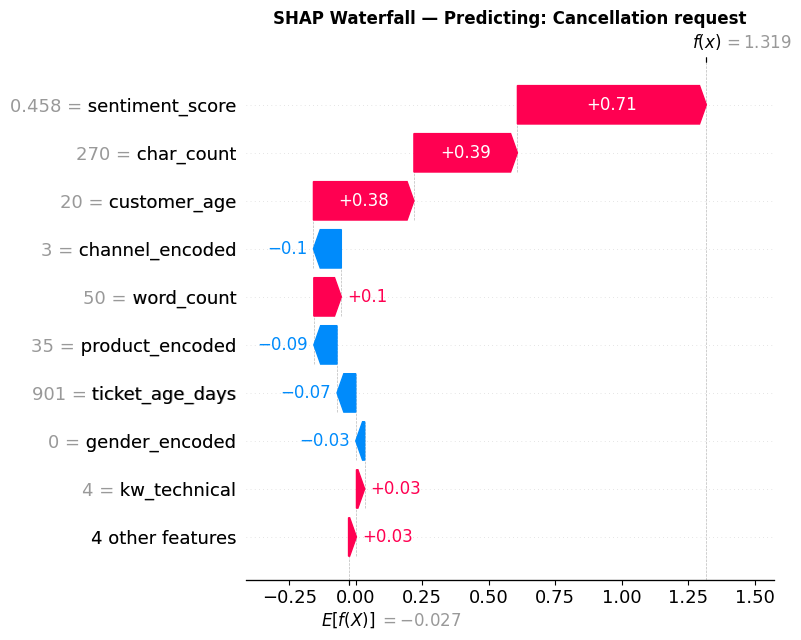

Waterfall plot saved!


In [7]:
# ============================================================
# CELL 7 — WATERFALL PLOT (single prediction explanation)
# ============================================================
sample_idx = 5   # pick a sample
pred_class = int(xgb_shap.predict(
    X_test_shap.iloc[[sample_idx]])[0])
true_class = int(y_test.iloc[sample_idx])

print(f"Sample index  : {sample_idx}")
print(f"True label    : {le_type.classes_[true_class]}")
print(f"Predicted     : {le_type.classes_[pred_class]}")
print(f"\nFeature values:")
for col in feature_cols:
    print(f"  {col:<25}: {X_test_shap.iloc[sample_idx][col]:.2f}")

# Extract SHAP values for this sample + predicted class
if shap_array.shape[1] == len(feature_cols):
    sample_shap = shap_array[sample_idx, :, pred_class]
    base_val    = explainer.expected_value[pred_class]
else:
    sample_shap = shap_array[pred_class][sample_idx]
    base_val    = explainer.expected_value[pred_class]

shap.waterfall_plot(
    shap.Explanation(
        values        = sample_shap,
        base_values   = base_val,
        data          = X_test_shap.iloc[sample_idx].values,
        feature_names = feature_cols
    ), show=False
)
plt.title(f'SHAP Waterfall — Predicting: {le_type.classes_[pred_class]}',
          fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'plots/shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved!")

In [8]:
# ============================================================
# CELL 8 — FINAL REPORT + SAVE EVERYTHING
# ============================================================
top5 = importance_df.head(5)

print("=" * 60)
print("SHAP EXPLAINABILITY REPORT — FINAL")
print("=" * 60)
print(f"Model         : XGBoost")
print(f"Features used : {xgb_shap.n_features_in_}")
print(f"Test samples  : {len(X_test_shap)}")
print(f"\nTop 5 features driving ticket type prediction:")
for _, row in top5.iterrows():
    bar = '█' * int(row['importance'] * 300)
    print(f"  {row['feature']:<25} "
          f"{row['importance']:.4f}  {bar}")

print(f"""
BUSINESS INSIGHTS:
  char_count / word_count → longer tickets = complex issues
  ticket_age_days         → older purchases = different types
  sentiment_score         → negative tone = billing/refund
  kw_technical            → technical words = tech tickets
  customer_age            → age affects ticket category

PLOTS SAVED:
  shap_global_importance.png
  shap_summary_<class>.png  (5 plots)
  shap_waterfall.png
""")

# Save all
importance_df.to_csv(BASE + 'shap_importance.csv', index=False)
joblib.dump(xgb_shap,  MODEL_DIR + 'xgb_shap.pkl')
joblib.dump(explainer, MODEL_DIR + 'shap_explainer.pkl')
print("All SHAP files saved!")
print("Next → FastAPI Deployment!")

SHAP EXPLAINABILITY REPORT — FINAL
Model         : XGBoost
Features used : 13
Test samples  : 1271

Top 5 features driving ticket type prediction:
  char_count                0.1595  ███████████████████████████████████████████████
  ticket_age_days           0.1595  ███████████████████████████████████████████████
  customer_age              0.1369  █████████████████████████████████████████
  word_count                0.1310  ███████████████████████████████████████
  sentiment_score           0.1232  ████████████████████████████████████

BUSINESS INSIGHTS:
  char_count / word_count → longer tickets = complex issues
  ticket_age_days         → older purchases = different types
  sentiment_score         → negative tone = billing/refund
  kw_technical            → technical words = tech tickets
  customer_age            → age affects ticket category

PLOTS SAVED:
  shap_global_importance.png
  shap_summary_<class>.png  (5 plots)
  shap_waterfall.png

All SHAP files saved!
Next → FastAPI De